In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
        "pavansubhasht/ibm-hr-analytics-attrition-dataset"
    )

print("Path to dataset files:", path)


Path to dataset files: C:\Users\OK\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1


In [ ]:
import os #os is used here to join the path and file name to get the full path of the csv file

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = os.path.join(path,"WA_Fn-UseC_-HR-Employee-Attrition.csv")
data = pd.read_csv(csv_path)
data.sample(10)
row,col = data.shape
print("Number of columns:", col)
print("Number of rows:", row)

Number of columns: 35
Number of rows: 1470


In [14]:
#Observation 
print("\n===== Target column: Attrition =====")
attrition_counts = data["Attrition"].value_counts()
left = attrition_counts.get("Yes", 0)
stayed = attrition_counts.get("No", 0)
attrition_rate = (left / row) * 100
 
print(f"Employees who left (Yes): {left}")
print(f"Employees who stayed (No): {stayed}")
print(f"Attrition rate: {attrition_rate:.2f}%")
print("\n===== Observation =====")
if attrition_rate < 35:
    balance_word = "imbalanced"
else:
    balance_word = "fairly balanced"
 
observation = (
        f"The dataset is {balance_word}: only {attrition_rate:.2f}% of employees\n"
        f"({left} out of {row}) left the company, while the remaining \n"
        f"{100 - attrition_rate:.2f}% ({stayed}) stayed. Because the 'Yes' (left) \n"
        f"class is the minority class, accuracy alone will be a misleading metric \n"
        f"for model evaluation - precision, recall, F1-score and ROC-AUC matter more, \n"
        f"and class_weight='balanced' should be used during model training (Task 4) \n"
        f"to prevent the models from simply predicting 'No' for everyone."
    )
print(observation)


===== Target column: Attrition =====
Employees who left (Yes): 237
Employees who stayed (No): 1233
Attrition rate: 16.12%

===== Observation =====
The dataset is imbalanced: only 16.12% of employees
(237 out of 1470) left the company, while the remaining 
83.88% (1233) stayed. Because the 'Yes' (left) 
class is the minority class, accuracy alone will be a misleading metric 
for model evaluation - precision, recall, F1-score and ROC-AUC matter more, 
and class_weight='balanced' should be used during model training (Task 4) 
to prevent the models from simply predicting 'No' for everyone.


In [ ]:
#Data cleaning and preprocessing
from sklearn.preprocessing import StandardScaler

# Columns that are constant or carry no predictive information.
COLUMNS_TO_DROP = ["EmployeeNumber", "Over18", "StandardHours", "EmployeeCount"]
null_counts = data.isnull().sum()
total_nulls = null_counts.sum()
print(f"\n===== Missing values =====")
if total_nulls == 0:
    print("No missing values found in the dataset.")
else:
    print(null_counts[null_counts > 0])
        # Numeric columns - fill with median; categorical - fill with mode
    for col in data.columns:
        if data[col].isnull().sum() > 0:
            if data[col].dtype in ["int64", "float64"]:
                data[col] = data[col].fillna(data[col].median())
            else:
                data[col] = data[col].fillna(data[col].mode()[0])
    print("Missing values have been imputed (median for numeric, mode for categorical).")
 
    
# 2. Drop irrelevant / constant columns
    
existing_drop_cols = [c for c in COLUMNS_TO_DROP if c in data.columns]
data = data.drop(columns=existing_drop_cols)
print(f"\n===== Dropped columns =====")
print(f"Dropped: {existing_drop_cols}")
print(f"Shape after dropping: {data.shape}")
 

# 3. Convert target column Attrition to 1/0 without breaking reruns.

if pd.api.types.is_numeric_dtype(data["Attrition"]):
    data["Attrition"] = data["Attrition"].astype(int)
else:
    data["Attrition"] = data["Attrition"].map({"Yes": 1, "No": 0})
print(f"\n===== Target column converted =====")
print(data["Attrition"].value_counts())
 
# -----------------------------------------------------------------
# 4. One-Hot Encode remaining categorical columns
# -----------------------------------------------------------------
categorical_cols = data.select_dtypes(include=["object"]).columns.tolist()
print(f"\n===== One-Hot Encoding =====")
print(f"Categorical columns encoded: {categorical_cols}")
 
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
print(f"Shape after one-hot encoding: {data_encoded.shape}")
 
   
 # 5. Scale numeric features with StandardScaler
    
# Scale every column except the target (Attrition) and the one-hot
# encoded dummy columns (which are already 0/1).
dummy_cols = [c for c in data_encoded.columns if c not in data.columns]
numeric_cols_to_scale = [
c for c in data_encoded.columns
if c not in dummy_cols and c != "Attrition"
]
 
scaler = StandardScaler()
data_encoded[numeric_cols_to_scale] = scaler.fit_transform(data_encoded[numeric_cols_to_scale])
 
print(f"\n===== Scaling =====")
print(f"Scaled {len(numeric_cols_to_scale)} numeric columns: {numeric_cols_to_scale}")
 
# -----------------------------------------------------------------
# 6. Save the cleaned dataset
# -----------------------------------------------------------------
CLEANED_CSV_NAME = "cleaned_hr_attrition.csv"
current_dir = os.getcwd() 
data_encoded.to_csv(current_dir + "/" + CLEANED_CSV_NAME, index=False)
print(f"\nCleaned dataset saved to: {current_dir + '/' + CLEANED_CSV_NAME}")
print(f"Final shape: {data_encoded.shape}")



===== Missing values =====
No missing values found in the dataset.

===== Dropped columns =====
Dropped: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
Shape after dropping: (1470, 31)

===== Target column converted =====
Attrition
0    1233
1     237
Name: count, dtype: int64

===== One-Hot Encoding =====
Categorical columns encoded: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after one-hot encoding: (1470, 45)

===== Scaling =====
Scaled 23 numeric columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


C:\Users\OK\AppData\Local\Temp\ipykernel_25552\2770956838.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=["object"]).columns.tolist()



Cleaned dataset saved to: f:\College\6th sem\HR_attrition/cleaned_hr_attrition.csv
Final shape: (1470, 45)


In [ ]:
#Task 3 - Exploratory Data Analysis (EDA)
def _attrition_positive_mask(series: pd.Series) -> pd.Series:
    """Return a boolean mask for employees who left, supporting text and numeric encodings."""
    if series.dtype == object:
        normalized = series.astype(str).str.strip().str.lower()
        return normalized.isin(["yes", "1", "true"])
    return series == 1


def attrition_rate_by(data: pd.DataFrame, column: str) -> pd.Series:
    """Returns the attrition rate (%) grouped by the given column, sorted descending."""
    rates = (
        data.groupby(column)["Attrition"]
        .apply(lambda x: _attrition_positive_mask(x).mean() * 100)
        .sort_values(ascending=False)
    )
    return rates.round(2)

dept_rates = attrition_rate_by(data, "Department")
print("===== Attrition rate by Department (%) =====")
print(dept_rates)
top_department = dept_rates.index[0]
 
  
# 2. Attrition rate by Job Role
  
role_rates = attrition_rate_by(data, "JobRole")
print("\n===== Attrition rate by Job Role (%) =====")
print(role_rates)
top_role = role_rates.index[0]
 
  
# 3. Attrition vs Monthly Income
  
income_by_attrition = data.groupby("Attrition")["MonthlyIncome"].agg(["mean", "median"]).round(2)
print("\n===== Monthly Income: left vs stayed =====")
print(income_by_attrition)
yes_key = 1 if 1 in income_by_attrition.index else "Yes"
no_key = 0 if 0 in income_by_attrition.index else "No"
income_left = income_by_attrition.loc[yes_key, "mean"]
income_stayed = income_by_attrition.loc[no_key, "mean"]
 
  
# 4. Attrition vs Work-Life Balance
wlb_rates = attrition_rate_by(data, "WorkLifeBalance")
print("\n===== Attrition rate by Work-Life Balance rating (%) =====")
print(wlb_rates.sort_index())
 
  
# 5. Attrition vs Years at Company (binned)
  
bins = [-1, 1, 3, 5, 10, 20, 100]
labels = ["0-1", "2-3", "4-5", "6-10", "11-20", "20+"]
data["TenureBand"] = pd.cut(data["YearsAtCompany"], bins=bins, labels=labels)
tenure_rates = attrition_rate_by(data, "TenureBand")
print("\n===== Attrition rate by Years-at-Company band (%) =====")
print(tenure_rates.sort_index())
peak_tenure_band = data.groupby("TenureBand")["Attrition"].apply(
    lambda x: _attrition_positive_mask(x).mean() * 100
).idxmax()
 
  
# 6. Written business insights (built from the numbers above)
  
print("\n===== Business Insights =====")
insights = [
    f"1. {top_department} has the highest attrition rate among departments at "
    f"{dept_rates.iloc[0]}%, making it the top priority area for retention efforts.",
 
    f"2. {top_role} is the single highest-risk job role for attrition at "
    f"{role_rates.iloc[0]}%, well above the company-wide average.",
 
    f"3. Employees who left earned an average monthly income of {income_left:,.0f} "
    f"compared to {income_stayed:,.0f} for those who stayed - a gap of "
    f"{income_stayed - income_left:,.0f}, suggesting lower pay is associated with "
    f"a higher likelihood of leaving.",
 
    f"4. Work-life balance rating shows a clear pattern: employees with a rating of "
    f"{wlb_rates.idxmax()} have the highest attrition rate at {wlb_rates.max()}%, "
    f"compared to {wlb_rates.min()}% for those with a rating of {wlb_rates.idxmin()}.",
 
    f"5. Attrition peaks in the {peak_tenure_band}-year tenure band, indicating this "
    f"is the most vulnerable point in an employee's lifecycle for the company to "
    f"focus retention conversations on.",
    ]
for line in insights:
    print(line)


===== Attrition rate by Department (%) =====
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

===== Attrition rate by Job Role (%) =====
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

===== Monthly Income: left vs stayed =====
              mean  median
Attrition                 
0          6832.74  5204.0
1          4787.09  3202.0

===== Attrition rate by Work-Life Balance rating (%) =====
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64

===== Attrition rate by Years-at-Company band (%) =====
TenureBand
0-1      34.88
2-3      18.43
4-5      13.07


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from sklearn.utils.class_weight import compute_sample_weight


X = data_encoded.drop(columns=["Attrition"])
y = data_encoded["Attrition"]
 
    # -----------------------------------------------------------------
    # 1. Train / test split (80/20, stratified to preserve class ratio)
    # -----------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape} | Test set: {X_test.shape}")
 
    # -----------------------------------------------------------------
    # 2. Train the 3 models with class_weight='balanced'
    #    (Gradient Boosting does not support class_weight directly, so we
    #    pass sample_weight computed the same way as 'balanced'.)
    # -----------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
        ),
        "Random Forest": RandomForestClassifier(
            class_weight="balanced", n_estimators=300, random_state=42
        ),
    }
 
# Gradient Boosting: emulate class_weight='balanced' via sample_weight
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
gb_model = GradientBoostingClassifier(n_estimators=300, random_state=42)
 
trained_models = {}
results = []
 
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    trained_models[name] = model
    results.append({"Model": name, "Test Accuracy": round(acc, 4)})
    print(f"Trained {name} | Test Accuracy: {acc:.4f}")
 
gb_model.fit(X_train, y_train, sample_weight=sample_weights)
gb_preds = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_preds)
trained_models["Gradient Boosting"] = gb_model
results.append({"Model": "Gradient Boosting", "Test Accuracy": round(gb_acc, 4)})
print(f"Trained Gradient Boosting | Test Accuracy: {gb_acc:.4f}")
 
    # -----------------------------------------------------------------
    # 3. Comparison table
    # -----------------------------------------------------------------
comparison_data = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
print("\n===== Model Comparison Table =====")
print(comparison_data.to_string(index=False))
 
 
   

Train set: (1176, 44) | Test set: (294, 44)
Trained Logistic Regression | Test Accuracy: 0.7551
Trained Random Forest | Test Accuracy: 0.8435
Trained Gradient Boosting | Test Accuracy: 0.8197

===== Model Comparison Table =====
              Model  Test Accuracy
      Random Forest         0.8435
  Gradient Boosting         0.8197
Logistic Regression         0.7551


In [ ]:
#5. Model Evaluation Metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

 
eval_rows = []
proba_by_model = {}
 
print("===== Per-model evaluation =====")
for name, model in trained_models.items():
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    proba_by_model[name] = proba
 
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, proba)
    cm = confusion_matrix(y_test, preds)
 
    eval_rows.append({
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        })
 
    print(f"\n--- {name} ---")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | "
        f"F1-Score: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(pd.DataFrame(
        cm,
        index=["Actual: Stayed (0)", "Actual: Left (1)"],
        columns=["Pred: Stayed (0)", "Pred: Left (1)"],
        ))
 
eval_df = pd.DataFrame(eval_rows).sort_values("ROC-AUC", ascending=False)
print("\n===== Evaluation Summary Table =====")
print(eval_df.to_string(index=False))
 
# -----------------------------------------------------------------
# Best model: ranked by ROC-AUC, since it best reflects performance
# on an imbalanced classification problem (more robust than accuracy)
# -----------------------------------------------------------------
best_model_name = eval_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"\n===== Best Model: {best_model_name} =====")
print(
    f"{best_model_name} was selected as the best model because it achieved the "
    f"highest ROC-AUC score ({eval_df.iloc[0]['ROC-AUC']:.4f}) on the held-out test "
    f"set, indicating the strongest overall ability to distinguish employees who "
    f"will leave from those who will stay across all classification thresholds - "
    f"a more reliable metric than raw accuracy on this imbalanced dataset."
)
 
# -----------------------------------------------------------------
# Feature importance / coefficients for the best model
# -----------------------------------------------------------------
feature_names = X_train.columns
 
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    importance_type = "Feature Importance"
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])
    importance_type = "Absolute Coefficient (importance proxy)"
else:
    importances = None
    importance_type = None
 
if importances is not None:
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        importance_type: importances,
    }).sort_values(importance_type, ascending=False)
    top10 = importance_df.head(10).reset_index(drop=True)
    print(f"\n===== Top 10 Most Important Features ({best_model_name}) =====")
    print(top10.to_string(index=False))
else:
    top10 = None
    print("\nSelected model does not expose feature importances or coefficients.")


===== Per-model evaluation =====

--- Logistic Regression ---
Precision: 0.3563 | Recall: 0.6596 | F1-Score: 0.4627 | ROC-AUC: 0.8036
Confusion Matrix:
                    Pred: Stayed (0)  Pred: Left (1)
Actual: Stayed (0)               191              56
Actual: Left (1)                  16              31

--- Random Forest ---
Precision: 0.5714 | Recall: 0.0851 | F1-Score: 0.1481 | ROC-AUC: 0.7819
Confusion Matrix:
                    Pred: Stayed (0)  Pred: Left (1)
Actual: Stayed (0)               244               3
Actual: Left (1)                  43               4

--- Gradient Boosting ---
Precision: 0.4286 | Recall: 0.3830 | F1-Score: 0.4045 | ROC-AUC: 0.7657
Confusion Matrix:
                    Pred: Stayed (0)  Pred: Left (1)
Actual: Stayed (0)               223              24
Actual: Left (1)                  29              18

===== Evaluation Summary Table =====
              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.3563  0.6596    0.4

C:\Users\OK\AppData\Local\Temp\ipykernel_25552\2526943008.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=department_rates.values, y=department_rates.index, ax=axes[0], palette="Blues_r")
C:\Users\OK\AppData\Local\Temp\ipykernel_25552\2526943008.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=jobrole_rates.values, y=jobrole_rates.index, ax=axes[1], palette="Greens_r")


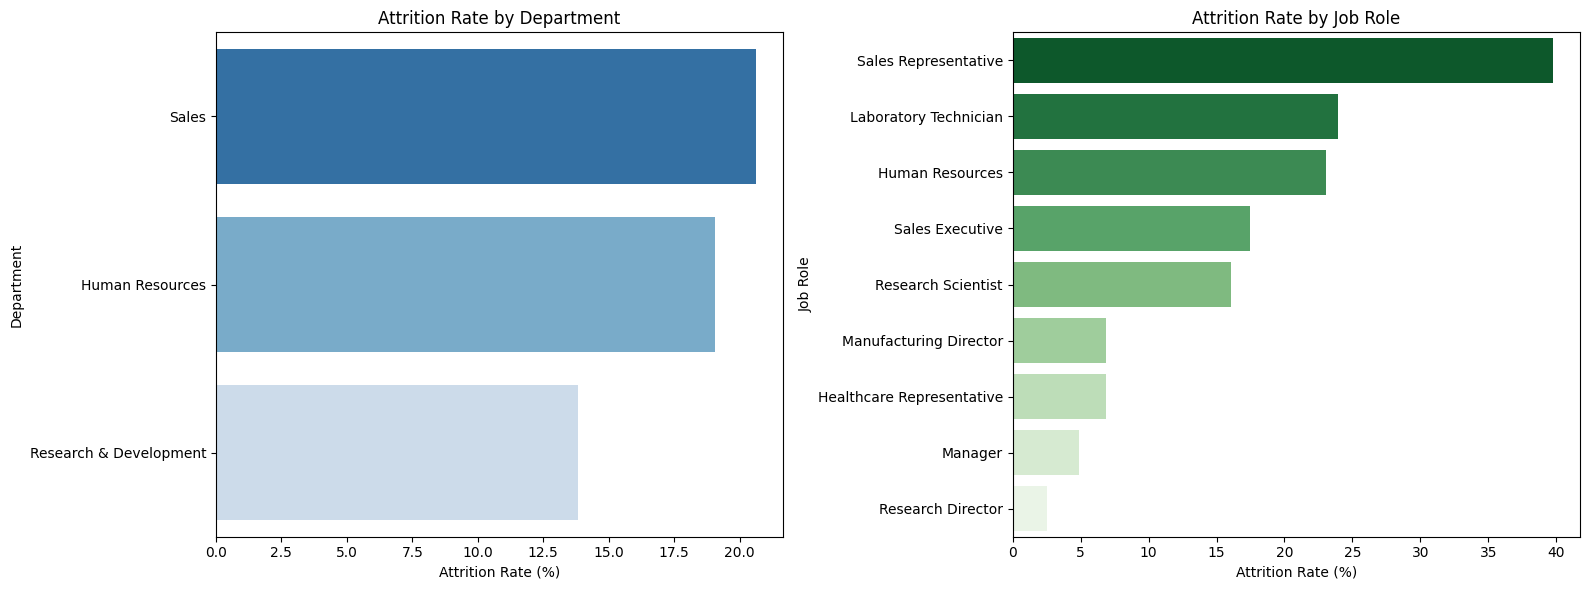

C:\Users\OK\AppData\Local\Temp\ipykernel_25552\2526943008.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_data, x="AttritionLabel", y="MonthlyIncome", palette=["#d95f02", "#1b9e77"])


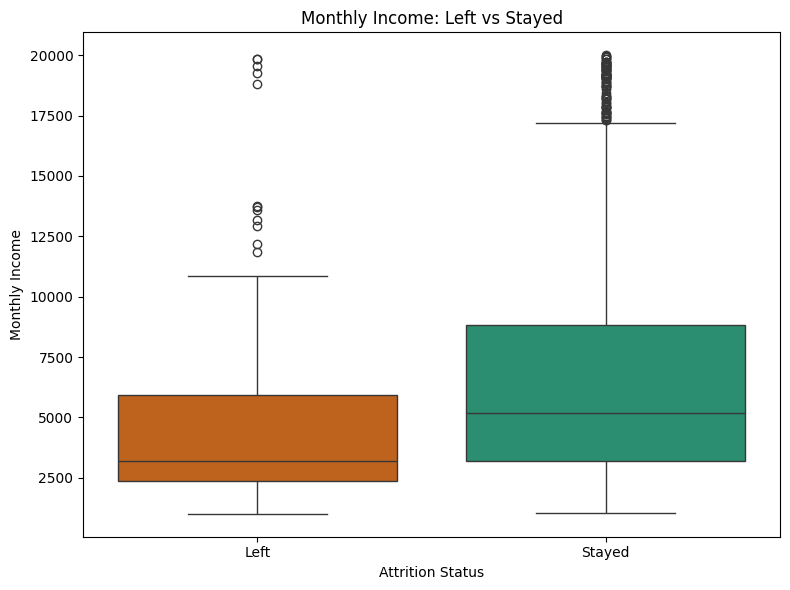

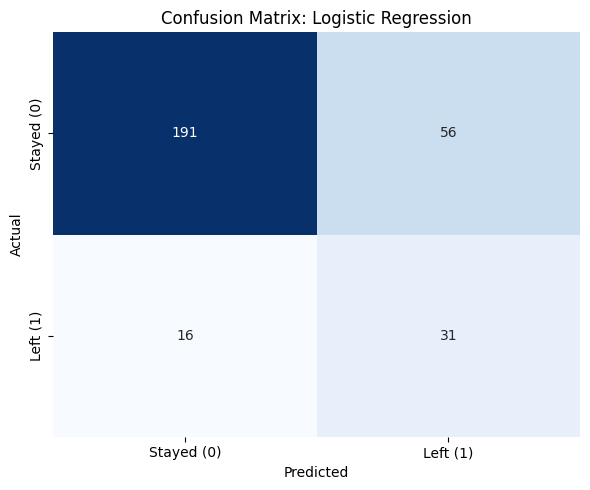

In [36]:
import seaborn as sns

# Chart 1: Bar charts for attrition rate by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

department_rates = attrition_rate_by(data, "Department")
jobrole_rates = attrition_rate_by(data, "JobRole")

sns.barplot(x=department_rates.values, y=department_rates.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Attrition Rate by Department")
axes[0].set_xlabel("Attrition Rate (%)")
axes[0].set_ylabel("Department")

sns.barplot(x=jobrole_rates.values, y=jobrole_rates.index, ax=axes[1], palette="Greens_r")
axes[1].set_title("Attrition Rate by Job Role")
axes[1].set_xlabel("Attrition Rate (%)")
axes[1].set_ylabel("Job Role")

plt.tight_layout()
plt.show()

# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
plt.figure(figsize=(8, 6))
box_data = data.copy()
box_data["AttritionLabel"] = box_data["Attrition"].map({1: "Left", 0: "Stayed"})
sns.boxplot(data=box_data, x="AttritionLabel", y="MonthlyIncome", palette=["#d95f02", "#1b9e77"])
plt.title("Monthly Income: Left vs Stayed")
plt.xlabel("Attrition Status")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()

# Chart 3: Confusion Matrix heatmap for the best model
best_preds = best_model.predict(X_test)
best_cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Stayed (0)", "Left (1)"],
    yticklabels=["Stayed (0)", "Left (1)"],
)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


C:\Users\OK\AppData\Local\Temp\ipykernel_25552\2474504960.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


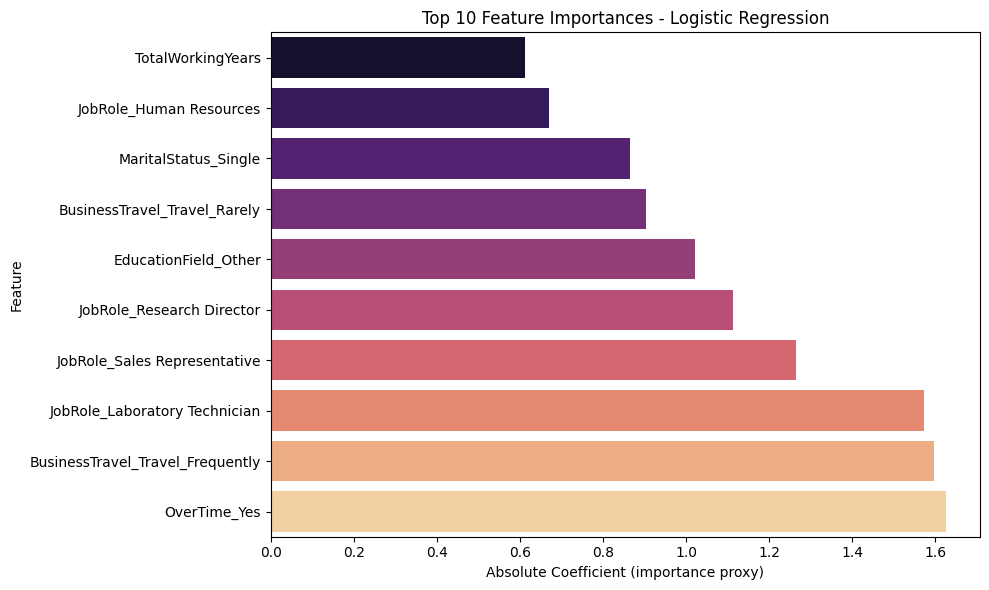

In [37]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from the best model
if top10 is not None:
    plt.figure(figsize=(10, 6))
    plot_feature_col = top10.columns[0]
    plot_value_col = top10.columns[1]
    plot_data = top10.sort_values(plot_value_col, ascending=True)

    sns.barplot(
        data=plot_data,
        x=plot_value_col,
        y=plot_feature_col,
        palette="magma",
    )
    plt.title(f"Top 10 Feature Importances - {best_model_name}")
    plt.xlabel(plot_value_col)
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Top 10 feature importance data is not available for the selected model.")


In [ ]:
# 7. Insights and Recommendations
paragraph = f"""
The analysis shows that attrition is concentrated in a few clear areas. Sales has the highest department-level attrition rate at {dept_rates.iloc[0]}%, \nwhile Sales Representative is the highest-risk role at {role_rates.iloc[0]}%. Employees who left also earned less on average than those who stayed, with a monthly income gap of {income_stayed - income_left:,.0f}, and the highest attrition appears in the {peak_tenure_band}-year tenure band. \nWork-life balance is another strong signal, with the lowest rating showing the highest churn.

For prediction, the best model was {best_model_name}, which achieved the highest ROC-AUC score in the model comparison. The most influential signals from that model were:
{', '.join(top10['Feature'].head(3).tolist()) if top10 is not None else 'the top model features identified in the evaluation cell'}.

Overall, the EDA and model evaluation agree on the same story: attrition is most likely where workload, compensation, tenure stage, \nand job context combine to create risk. HR should prioritize retention efforts in the Sales function, especially for Sales Representatives, and focus on employees with weak work-life \nbalance or early tenure patterns.
"""
print(paragraph)



The analysis shows that attrition is concentrated in a few clear areas. Sales has the highest department-level attrition rate at 20.63%, 
while Sales Representative is the highest-risk role at 39.76%. Employees who left also earned less on average than those who stayed, with a monthly income gap of 2,046, and the highest attrition appears in the 0-1-year tenure band. 
Work-life balance is another strong signal, with the lowest rating showing the highest churn.

For prediction, the best model was Logistic Regression, which achieved the highest ROC-AUC score in the model comparison. The most influential signals from that model were:
OverTime_Yes, BusinessTravel_Travel_Frequently, JobRole_Laboratory Technician.

Overall, the EDA and model evaluation agree on the same story: attrition is most likely where workload, compensation, tenure stage, 
and job context combine to create risk. HR should prioritize retention efforts in the Sales function, especially for Sales Representatives, and foc